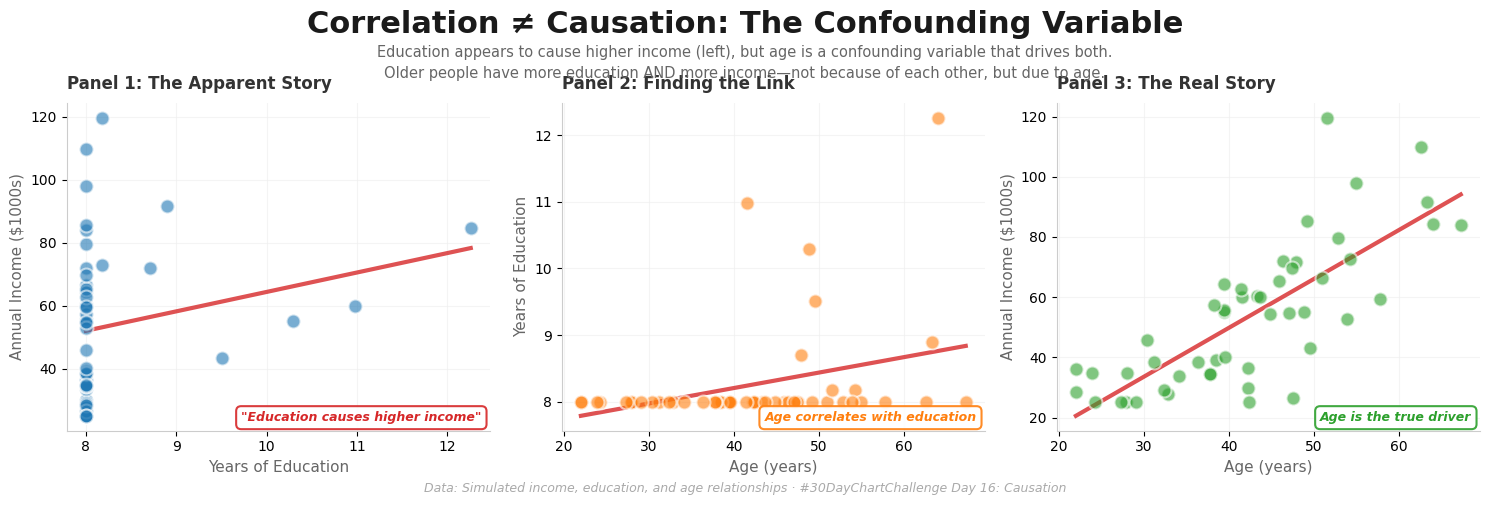

In [1]:
"""
#30DayChartChallenge — Day 16: Causation
"Correlation ≠ Causation: The Confounding Variable" — revealing hidden drivers
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Education, income, and age relationships (demonstrating confounding)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Education, income, and age
# ---------------------------------------------------------------------------
np.random.seed(42)

data = {
    "Person": [f"Person {i}" for i in range(1, 51)],
    "Age": np.random.normal(45, 12, 50),
    "Years_Education": np.random.normal(14, 3, 50),
    "Annual_Income": np.random.normal(70000, 25000, 50)
}

df = pd.DataFrame(data)

# Make education and income moderately correlated
df["Years_Education"] = (df["Age"] / 60 * 8 + np.random.normal(0, 2, 50)).clip(8, 20)
df["Annual_Income"] = (df["Age"] / 50 * 60000 + np.random.normal(0, 15000, 50)).clip(25000, 180000)

# Ensure all values are reasonable
df["Age"] = df["Age"].clip(22, 70)
df["Years_Education"] = df["Years_Education"].clip(8, 20)
df["Annual_Income"] = df["Annual_Income"].clip(25000, 180000)

# ---------------------------------------------------------------------------
# 2. PLOT — Three panels revealing the confounding variable
# ---------------------------------------------------------------------------
fig = plt.figure(figsize=(15, 5), facecolor="#FFFFFF")

# Panel 1: Apparent causation (Education → Income)
ax1 = fig.add_subplot(131)
ax1.set_facecolor("#FFFFFF")

scatter1 = ax1.scatter(df["Years_Education"], df["Annual_Income"] / 1000,
                       s=100, color="#1f77b4", alpha=0.6, edgecolor="white", linewidth=1.5, zorder=3)

# Regression line
z1 = np.polyfit(df["Years_Education"], df["Annual_Income"] / 1000, 1)
p1 = np.poly1d(z1)
x_line1 = np.linspace(df["Years_Education"].min(), df["Years_Education"].max(), 100)
ax1.plot(x_line1, p1(x_line1), color="#d62728", linewidth=3, alpha=0.8, zorder=2, label="Apparent trend")

ax1.set_xlabel("Years of Education", fontsize=11, color="#666666", fontweight="500")
ax1.set_ylabel("Annual Income ($1000s)", fontsize=11, color="#666666", fontweight="500")
ax1.set_title("Panel 1: The Apparent Story", fontsize=12, fontweight="bold", color="#333333", loc="left", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#cccccc")
ax1.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax1.set_axisbelow(True)

ax1.text(0.98, 0.02, "\"Education causes higher income\"",
         fontsize=9, fontweight="bold", color="#d62728", transform=ax1.transAxes,
         ha="right", va="bottom", style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#d62728", linewidth=1.5, alpha=0.9))

# Panel 2: Age vs Education
ax2 = fig.add_subplot(132)
ax2.set_facecolor("#FFFFFF")

scatter2 = ax2.scatter(df["Age"], df["Years_Education"],
                       s=100, color="#ff7f0e", alpha=0.6, edgecolor="white", linewidth=1.5, zorder=3)

z2 = np.polyfit(df["Age"], df["Years_Education"], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df["Age"].min(), df["Age"].max(), 100)
ax2.plot(x_line2, p2(x_line2), color="#d62728", linewidth=3, alpha=0.8, zorder=2)

ax2.set_xlabel("Age (years)", fontsize=11, color="#666666", fontweight="500")
ax2.set_ylabel("Years of Education", fontsize=11, color="#666666", fontweight="500")
ax2.set_title("Panel 2: Finding the Link", fontsize=12, fontweight="bold", color="#333333", loc="left", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#cccccc")
ax2.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax2.set_axisbelow(True)

ax2.text(0.98, 0.02, "Age correlates with education",
         fontsize=9, fontweight="bold", color="#ff7f0e", transform=ax2.transAxes,
         ha="right", va="bottom", style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#ff7f0e", linewidth=1.5, alpha=0.9))

# Panel 3: Age vs Income (the real driver)
ax3 = fig.add_subplot(133)
ax3.set_facecolor("#FFFFFF")

scatter3 = ax3.scatter(df["Age"], df["Annual_Income"] / 1000,
                       s=100, color="#2ca02c", alpha=0.6, edgecolor="white", linewidth=1.5, zorder=3)

z3 = np.polyfit(df["Age"], df["Annual_Income"] / 1000, 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df["Age"].min(), df["Age"].max(), 100)
ax3.plot(x_line3, p3(x_line3), color="#d62728", linewidth=3, alpha=0.8, zorder=2)

ax3.set_xlabel("Age (years)", fontsize=11, color="#666666", fontweight="500")
ax3.set_ylabel("Annual Income ($1000s)", fontsize=11, color="#666666", fontweight="500")
ax3.set_title("Panel 3: The Real Story", fontsize=12, fontweight="bold", color="#333333", loc="left", pad=10)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#cccccc")
ax3.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax3.set_axisbelow(True)

ax3.text(0.98, 0.02, "Age is the true driver",
         fontsize=9, fontweight="bold", color="#2ca02c", transform=ax3.transAxes,
         ha="right", va="bottom", style="italic",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#fff", edgecolor="#2ca02c", linewidth=1.5, alpha=0.9))

# Overall title & subtitle
fig.text(0.5, 0.98, "Correlation ≠ Causation: The Confounding Variable",
         fontsize=22, fontweight="bold", color="#1a1a1a", ha="center", va="top")

fig.text(0.5, 0.91,
         "Education appears to cause higher income (left), but age is a confounding variable that drives both.\n"
         "Older people have more education AND more income—not because of each other, but due to age.",
         fontsize=10.5, color="#666666", ha="center", va="top", linespacing=1.5)

# Source
fig.text(0.5, 0.01,
         "Data: Simulated income, education, and age relationships · #30DayChartChallenge Day 16: Causation",
         fontsize=9, color="#aaaaaa", style="italic", ha="center", va="bottom")

plt.tight_layout(rect=[0, 0.02, 1, 0.88])
plt.savefig("day16_causation.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()